# 🩻 Día 2 — Segmentación de Radiografías con MedSAM (BATCH)

## 📋 Objetivos del Día 2

✅ Definir la estrategia de prompting para MedSAM (bounding boxes o puntos)  
✅ Aplicar MedSAM a 50-100 radiografías y guardar máscaras  
✅ Evaluar visualmente la calidad de segmentación  
✅ Documentar casos de fallo y causas  

## 🎯 Estrategia

Procesaremos imágenes del dataset CNN desde la carpeta `imagenes_procesadas`

---

## 0️⃣ Instalación de Dependencias

In [61]:
# Instalar segment-anything desde GitHub
#!pip install -q git+https://github.com/facebookresearch/segment-anything.git

# Instalar otras dependencias
#!pip install -q opencv-python scikit-image tqdm

#print("✅ Dependencias instaladas")

## 1️⃣ Importar Librerías y Configurar

In [62]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import cv2
from pathlib import Path
from tqdm import tqdm
from segment_anything import sam_model_registry, SamPredictor

print("✅ Librerías importadas correctamente")
print(f"   PyTorch: {torch.__version__}")
print(f"   NumPy: {np.__version__}")

✅ Librerías importadas correctamente
   PyTorch: 2.11.0+cpu
   NumPy: 2.4.4


## 2️⃣ Configurar Rutas y Dispositivo

### 📁 Estructura del Dataset

```
CNN_desde_0/
└── imagenes_procesadas/
    ├── train/
    │   ├── si/      ← Imágenes con anatomía correcta
    │   └── no/      ← Imágenes con anatomía incorrecta
    └── test/
        ├── si/
        └── no/
```

### 🎯 Opciones de Procesamiento

Puedes elegir procesar:
- `train/si` - Imágenes de entrenamiento correctas
- `train/no` - Imágenes de entrenamiento incorrectas
- `test/si` - Imágenes de test correctas
- `test/no` - Imágenes de test incorrectas

In [63]:
# --- CONFIGURACIÓN DE RUTAS ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Dispositivo seleccionado: {device.upper()}\n")

# Ruta del modelo
checkpoint_path = "../Dia1/medsam_vit_b.pth"

# RUTA CORREGIDA: Carpeta principal de imágenes procesadas
input_dir = "../../CNN_desde_0/imagenes_procesadas"
output_dir = "mascaras_segmentadas_todas"

print("📁 RUTAS CONFIGURADAS:")
print(f"   Entrada: {input_dir}")
print(f"   Salida: {output_dir}\n")

# Crear carpeta de salida
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Verificar que exista el checkpoint
if not os.path.exists(checkpoint_path):
    print(f"❌ Checkpoint no encontrado: {checkpoint_path}")
    print(f"   Descárgalo desde: https://drive.google.com/file/d/1UAmWL88roYR7wKlnApw5Bcuzf2iQgk6_/view?usp=sharing")
else:
    print(f"✅ Checkpoint encontrado\n")

# Verificar que exista la carpeta de entrada
if not os.path.exists(input_dir):
    print(f"❌ Carpeta de entrada no encontrada: {input_dir}")
    print(f"   Verifica la ruta y la estructura del proyecto")
    print(f"\n   Directorio actual: {os.getcwd()}")
else:
    # BUSCAR TODAS LAS IMÁGENES EN TODAS LAS SUBCARPETAS
    image_extensions = ['.png', '.jpg', '.jpeg', '.bmp', '.tiff']
    image_files = []
    image_paths = {}  # Guardar ruta completa + nombre
    
    # Recorrer todas las subcarpetas
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if any(file.lower().endswith(ext) for ext in image_extensions):
                full_path = os.path.join(root, file)
                image_files.append(file)
                image_paths[file] = full_path
    
    print(f"✅ Carpeta de entrada encontrada")
    print(f"   📸 Imágenes encontradas: {len(image_files)}\n")
    
    # Mostrar estructura de carpetas
    print("📂 Estructura de carpetas:")
    for root, dirs, files in os.walk(input_dir):
        level = root.replace(input_dir, '').count(os.sep)
        indent = '   ' * (level + 1)
        print(f"{indent}{os.path.basename(root)}/")
        for file in files:
            if any(file.lower().endswith(ext) for ext in image_extensions):
                print(f"{indent}   - {file}")

🖥️  Dispositivo seleccionado: CPU

📁 RUTAS CONFIGURADAS:
   Entrada: ../../CNN_desde_0/imagenes_procesadas
   Salida: mascaras_segmentadas_todas

✅ Checkpoint encontrado

✅ Carpeta de entrada encontrada
   📸 Imágenes encontradas: 70

📂 Estructura de carpetas:
   imagenes_procesadas/
      test/
         no/
            - img_1776864630193.png
            - img_1776864644631.png
            - img_1777026670875.png
            - img_1777027201011.png
            - img_1777027661410.png
            - img_1777027673930.png
            - img_1777028297087.png
            - img_1777028325664.png
            - img_1777028637517.png
         si/
            - img_1776863513281.png
            - img_1776863889130.png
            - img_1776863909985.png
            - img_1777026517084.png
            - img_1777026555963.png
            - img_1777027170211.png
            - img_1777027595858.png
            - img_1777028264615.png
      train/
         no/
            - img_1776863844568.png
    

## 3️⃣ Cargar Modelo MedSAM

### Configuración
- **Modelo**: ViT-B (Vision Transformer Base)
- **Entrada**: Imagen codificada
- **Salida**: Máscara de segmentación + Score de confianza

In [64]:
print("⏳ Cargando modelo MedSAM...\n")

try:
    # Crear instancia
    medsam_model = sam_model_registry["vit_b"]()
    print("   ✓ Modelo instanciado")
    
    # Cargar pesos
    with open(checkpoint_path, "rb") as f:
        state_dict = torch.load(f, map_location="cpu")
    medsam_model.load_state_dict(state_dict)
    print("   ✓ Pesos cargados")
    
    # Mover a dispositivo
    medsam_model.to(device)
    medsam_model.eval()
    print("   ✓ Modelo en dispositivo")
    
    print(f"\n✅ Modelo cargado exitosamente en {device.upper()}")
    
except FileNotFoundError:
    print(f"❌ Error: No se encontró {checkpoint_path}")
    raise
except Exception as e:
    print(f"❌ Error al cargar: {e}")
    raise

⏳ Cargando modelo MedSAM...

   ✓ Modelo instanciado
   ✓ Pesos cargados
   ✓ Modelo en dispositivo

✅ Modelo cargado exitosamente en CPU


## 4️⃣ Definir Estrategia de Prompting

### 📌 Opciones de Input

| Método | Descripción | Ventaja |
|--------|-------------|----------|
| **Bounding Box** | Caja que delimita la estructura | Rápido, automático |
| **Puntos** | Clicks dentro de la anatomía | Más preciso, interactivo |
| **Ambos** | Combinación de box + puntos | Óptimo, pero más lento |

### 🎯 Estrategia Elegida: **Bounding Box Automático**

Detectaremos automáticamente la región más importante de cada radiografía.

In [65]:
def obtener_bounding_box_automatico(imagen_np, margen=30):
    if len(imagen_np.shape) == 3:
        gray = cv2.cvtColor(imagen_np, cv2.COLOR_RGB2GRAY)
    else:
        gray = imagen_np
    
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        h, w = gray.shape
        return np.array([0, 0, w, h])
    
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    
    x_min = max(0, x - margen)
    y_min = max(0, y - margen)
    x_max = min(imagen_np.shape[1], x + w + margen)
    y_max = min(imagen_np.shape[0], y + h + margen)
    
    return np.array([x_min, y_min, x_max, y_max])

## 5️⃣ Procesar Dataset en Batch

### 🔄 Pipeline

1. **Cargar imagen** → Array NumPy
2. **Detectar box** → Bounding box automático
3. **Segmentar** → MedSAM genera máscara
4. **Guardar** → Máscara en PNG
5. **Registrar** → Score y metadata

### 📊 Salida

- Máscara PNG para cada imagen
- CSV con scores y metadata
- Reporte de errores

In [66]:
def segmentar_dataset(input_dir, output_dir, medsam_model, predictor, device, max_images=None):
    """
    Procesa todas las imágenes del dataset con MedSAM
    ✅ VERSIÓN FINAL: Bounding box + multimask (simple y efectivo)
    """
    stats = {
        'total': 0,
        'exitosas': 0,
        'errores': 0,
        'scores': [],
        'archivos_procesados': [],
        'errores_detallados': []
    }
    
    image_extensions = ['.png', '.jpg', '.jpeg', '.bmp', '.tiff']
    all_images = []
    
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if any(file.lower().endswith(ext) for ext in image_extensions):
                full_path = os.path.join(root, file)
                relative_path = os.path.relpath(root, input_dir)
                all_images.append((file, full_path, relative_path))
    
    if max_images:
        all_images = all_images[:max_images]
    
    stats['total'] = len(all_images)
    
    for filename, full_path, relative_path in tqdm(all_images, desc="Procesando radiografías"):
        try:
            image = cv2.imread(full_path)
            if image is None:
                raise ValueError("No se pudo cargar la imagen")
            
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            predictor.set_image(image_rgb)
            
            gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
            gray_inv = 255 - gray
            
            _, binary = cv2.threshold(gray_inv, 100, 255, cv2.THRESH_BINARY)
            contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            if contours:
                largest_contour = max(contours, key=cv2.contourArea)
                x, y, w, h = cv2.boundingRect(largest_contour)
                
                margen = 30
                input_box = np.array([
                    max(0, x - margen),
                    max(0, y - margen),
                    min(image_rgb.shape[1], x + w + margen),
                    min(image_rgb.shape[0], y + h + margen)
                ])
            else:
                h, w = image_rgb.shape[:2]
                input_box = np.array([0, 0, w, h])
            
            masks, scores, logits = predictor.predict(
                box=input_box,
                multimask_output=True
            )
            
            best_idx = np.argmax(scores)
            mask = masks[best_idx]
            score = scores[best_idx]
            
            output_subdir = os.path.join(output_dir, relative_path)
            Path(output_subdir).mkdir(parents=True, exist_ok=True)
            
            mask_filename = filename.replace(filename.split('.')[-1], 'png')
            mask_path = os.path.join(output_subdir, f"mask_{mask_filename}")
            
            mask_uint8 = (mask.astype(np.uint8) * 255)
            cv2.imwrite(mask_path, mask_uint8)
            
            overlay = image_rgb.copy()
            overlay[mask] = [0, 255, 0]
            overlay_img = cv2.addWeighted(image_rgb, 0.7, overlay, 0.3, 0)
            
            overlay_path = os.path.join(output_subdir, f"overlay_{mask_filename}")
            overlay_bgr = cv2.cvtColor(overlay_img, cv2.COLOR_RGB2BGR)
            cv2.imwrite(overlay_path, overlay_bgr)
            
            stats['archivos_procesados'].append({
                'imagen': filename,
                'mascara': f"mask_{mask_filename}",
                'score': float(score),
                'box': str(input_box.tolist()),
                'ruta': relative_path
            })
            
            stats['exitosas'] += 1
            stats['scores'].append(float(score))
            
        except Exception as e:
            stats['errores'] += 1
            stats['errores_detallados'].append({
                'imagen': filename,
                'error': str(e)
            })
    
    return stats

# 🔍 Debuggeo de Segmentación - Qué Hace

## ¿Cuál es el objetivo?

Visualizar **3 cosas a la vez** para entender si MedSAM está funcionando bien:

1. **Imagen Original** → La radiografía normal
2. **Bounding Box** → Rectángulo verde mostrando dónde MedSAM busca
3. **Máscara** → Resultado: blanco = dedo detectado, negro = fondo

---

## 🎯 Paso a Paso

**1. Cargar imagen**
```python
image = cv2.imread(test_image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
```
→ Lee la radiografía

**2. Detectar dónde está el dedo**
```python
bbox = obtener_bounding_box_automatico(image_rgb, margen=30)
```
→ Obtiene coordenadas del bounding box

**3. Dibujar el bounding box**
```python
cv2.rectangle(image_with_box, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
```
→ Dibuja rectángulo verde

**4. Hacer predicción con MedSAM**
```python
predictor.set_image(image_rgb)
masks, scores, logits = predictor.predict(box=bbox, multimask_output=False)
```
→ MedSAM segmenta usando el bounding box

**5. Mostrar los 3 gráficos**
```python
plt.subplot(1, 3, 1)  # Imagen original
plt.subplot(1, 3, 2)  # Imagen + bounding box
plt.subplot(1, 3, 3)  # Máscara resultado
```
→ Visualiza todo junto

---

## ✅ Cuándo está bien

- El bbox rodea completamente el dedo
- La máscara blanca cubre todo el dedo
- Score > 0.7

## ❌ Cuándo está mal

- El bbox es demasiado pequeño/grande
- La máscara segmenta cosas equivocadas
- Score < 0.6

Bounding box detectado: [121  88 592 391]
Bounding box: [121  88 592 391]
Mejor score de 3: 0.6396


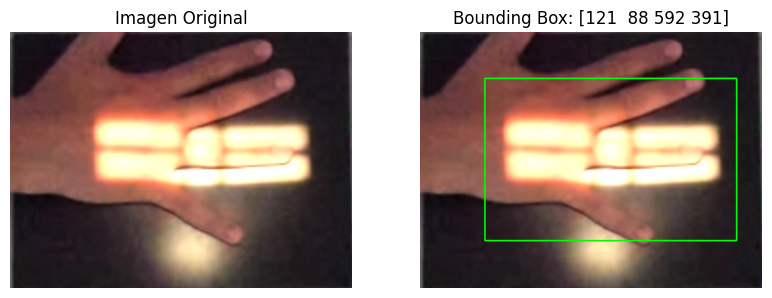

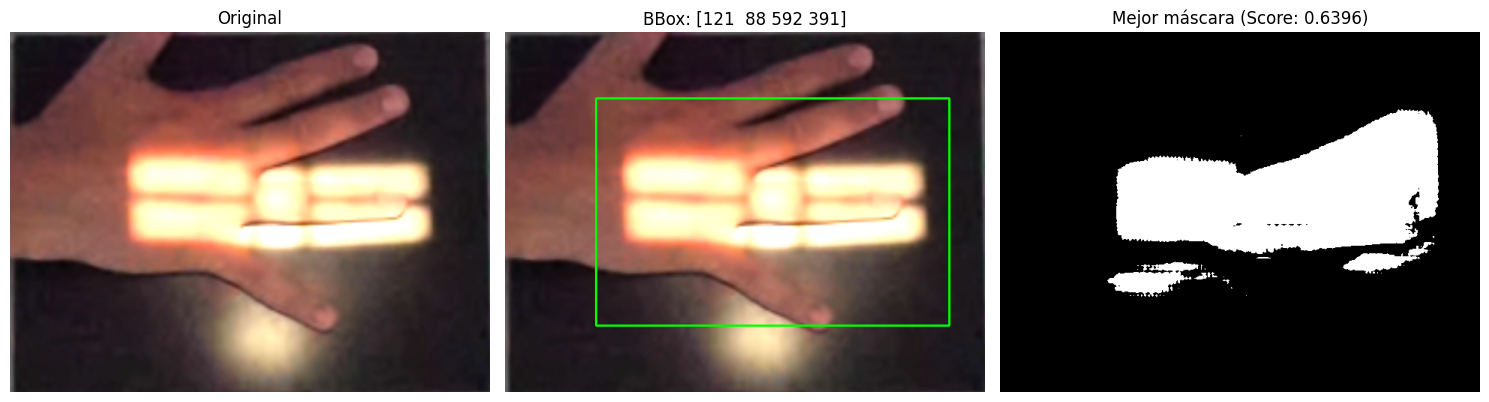

In [67]:
# Crear predictor
predictor = SamPredictor(medsam_model)

# ===== AHORA SÍ PUEDES HACER EL DEBUGGEO =====

# DEBUGGEO: Procesa solo 1 imagen para ver qué pasa
test_image_path = "c:/Users/carlo/Desktop/Proyecte_RX/ProyectoFinal_CSEBDIA/CNN_desde_0/imagenes_procesadas/test/si/img_1776863513281.png"

image = cv2.imread(test_image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Ver la imagen
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Imagen Original")
plt.axis('off')

# Ver el bounding box detectado
bbox = obtener_bounding_box_automatico(image_rgb, margen=30)
print(f"Bounding box detectado: {bbox}")

# Dibujar el bounding box
image_with_box = image_rgb.copy()
cv2.rectangle(image_with_box, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)

plt.subplot(1, 3, 2)
plt.imshow(image_with_box)
plt.title(f"Bounding Box: {bbox}")
plt.axis('off')

## Debuggeo SIMPLE
predictor.set_image(image_rgb)

# Usar SOLO el bounding box original (sin invertir)
bbox = obtener_bounding_box_automatico(image_rgb, margen=30)

print(f"Bounding box: {bbox}")

# Predicción SIMPLE
masks, scores, logits = predictor.predict(
    box=bbox,
    multimask_output=True  # ✅ IMPORTANTE: True para obtener 3 máscaras
)

# MedSAM devuelve 3 máscaras, elige la mejor
best_idx = np.argmax(scores)
mask = masks[best_idx]
score = scores[best_idx]

print(f"Mejor score de 3: {score:.4f}")

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 3, 2)
image_with_box = image_rgb.copy()
cv2.rectangle(image_with_box, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
plt.imshow(image_with_box)
plt.title(f"BBox: {bbox}")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(mask, cmap='gray')
plt.title(f"Mejor máscara (Score: {score:.4f})")
plt.axis('off')

plt.tight_layout()
plt.show()

Bounding box: [  0   0 640 480]
Puntos: [[np.int64(9), np.int64(114)], [np.int64(144), np.int64(335)], [np.int64(86), np.int64(122)], [np.int64(286), np.int64(153)], [np.int64(124), np.int64(11)]]
Scores: [0.5584352  0.53148806 0.35645646]
Mejor score: 0.5584


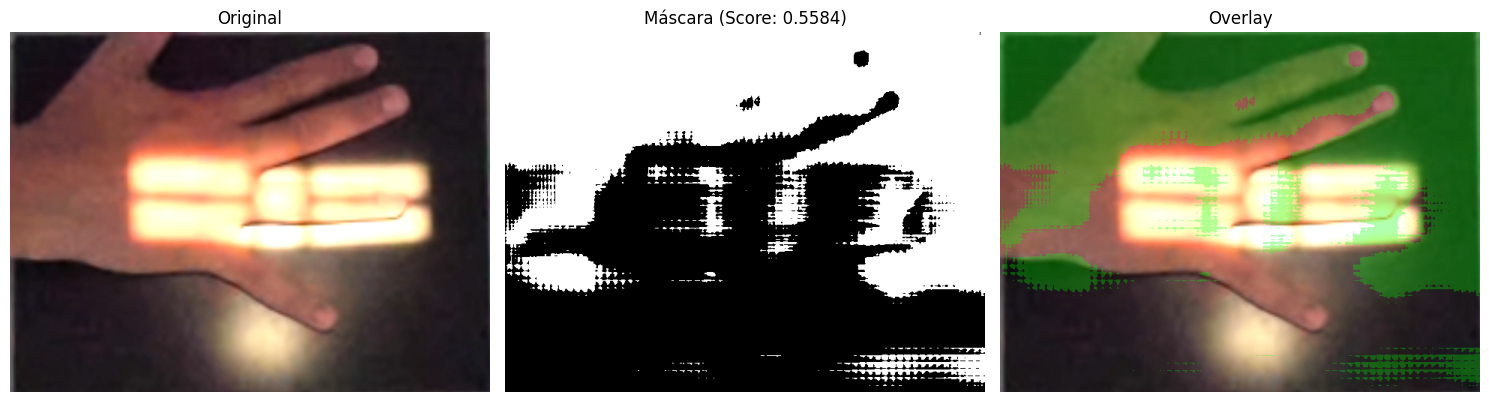

In [68]:
# DEBUGGEO CON LA NUEVA FUNCIÓN
predictor = SamPredictor(medsam_model)

test_image_path = "c:/Users/carlo/Desktop/Proyecte_RX/ProyectoFinal_CSEBDIA/CNN_desde_0/imagenes_procesadas/test/si/img_1776863513281.png"

image = cv2.imread(test_image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

predictor.set_image(image_rgb)

# ✅ NUEVA ESTRATEGIA: Múltiples puntos en píxeles oscuros
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
gray_inv = 255 - gray

# Cambiar SOLO esta línea:
_, binary = cv2.threshold(gray_inv, 100, 255, cv2.THRESH_BINARY)  # Aumenta de 100 a 150

contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    
    margen = 30
    input_box = np.array([
        max(0, x - margen),
        max(0, y - margen),
        min(image_rgb.shape[1], x + w + margen),
        min(image_rgb.shape[0], y + h + margen)
    ])
else:
    h, w = image_rgb.shape[:2]
    input_box = np.array([0, 0, w, h])

print(f"Bounding box: {input_box}")

# ✅ Detectar múltiples puntos en píxeles oscuros
coords = np.where(binary > 0)

if len(coords[0]) > 0:
    indices = np.random.choice(len(coords[0]), size=min(5, len(coords[0])), replace=False)
    
    input_points = []
    for idx in indices:
        x = coords[1][idx]
        y = coords[0][idx]
        input_points.append([x, y])
    
    input_point = np.array(input_points)
    input_label = np.array([1] * len(input_points))
    
    print(f"Puntos: {input_points}")
    
    masks, scores, logits = predictor.predict(
        box=input_box,
        point_coords=input_point,
        point_labels=input_label,
        multimask_output=True
    )
else:
    masks, scores, logits = predictor.predict(
        box=input_box,
        multimask_output=True
    )

print(f"Scores: {scores}")

best_idx = np.argmax(scores)
mask = masks[best_idx]
score = scores[best_idx]

print(f"Mejor score: {score:.4f}")

# Visualizar
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title(f"Máscara (Score: {score:.4f})")
plt.axis('off')

plt.subplot(1, 3, 3)
overlay = image_rgb.copy()
overlay[mask] = [0, 255, 0]
overlay_img = cv2.addWeighted(image_rgb, 0.7, overlay, 0.3, 0)
plt.imshow(overlay_img)
plt.title("Overlay")
plt.axis('off')

plt.tight_layout()
plt.show()

## 6️⃣ Ejecutar Segmentación en Batch

### ⚠️ Importante

- **Carpeta de entrada**: Debe contener las radiografías
- **Tiempo estimado**: ~30-60 segundos por imagen (CPU), ~5-10 segundos (GPU)
- **Ajusta `max_images`** si quieres procesar un subconjunto
  - `max_images=10` → Procesa las primeras 10 imágenes (para pruebas rápidas)
  - `max_images=50` → Procesa 50 imágenes
  - `max_images=None` → Procesa TODAS las imágenes

In [69]:
# Crear predictor
predictor = SamPredictor(medsam_model)

# Ejecutar procesamiento
# AJUSTA max_images según necesites:
# - 10 para una prueba rápida
# - 50-100 para el dataset completo
# - None para procesar TODAS

stats = segmentar_dataset(
    input_dir=input_dir,
    output_dir=output_dir,
    medsam_model=medsam_model,
    predictor=predictor,
    device=device,
    max_images=None  # Cambia a None para procesar TODAS
)

print("\n" + "="*60)
print("📊 RESUMEN DEL PROCESAMIENTO")
print("="*60)
print(f"Total procesadas: {stats['total']}")
print(f"Exitosas: {stats['exitosas']} ✅")
print(f"Errores: {stats['errores']} ❌")

# ✅ ARREGLO: Verifica si hay datos antes de dividir
if stats['total'] > 0:
    print(f"Tasa de éxito: {(stats['exitosas']/stats['total']*100):.1f}%")
else:
    print("⚠️  No se procesó ninguna imagen")

# ✅ ARREGLO: Verifica si hay scores antes de procesarlos
if stats['scores'] and len(stats['scores']) > 0:
    scores_array = np.array(stats['scores'])
    print(f"\n📈 Estadísticas de Scores:")
    print(f"  Media: {scores_array.mean():.4f}")
    print(f"  Mín: {scores_array.min():.4f}")
    print(f"  Máx: {scores_array.max():.4f}")
    print(f"  Desv. Est: {scores_array.std():.4f}")
    
    # Imágenes con baja confianza
    low_score_count = (scores_array < 0.6).sum()
    print(f"\n⚠️  Imágenes con score < 0.6: {low_score_count} ({low_score_count/len(scores_array)*100:.1f}%)")
else:
    print("⚠️  No hay scores disponibles para mostrar estadísticas")

if stats['errores_detallados']:
    print(f"\n❌ Primeros 5 errores:")
    for error in stats['errores_detallados'][:5]:
        print(f"  - {error['imagen']}: {error['error']}")

Procesando radiografías: 100%|██████████| 70/70 [05:46<00:00,  4.95s/it]


📊 RESUMEN DEL PROCESAMIENTO
Total procesadas: 70
Exitosas: 70 ✅
Errores: 0 ❌
Tasa de éxito: 100.0%

📈 Estadísticas de Scores:
  Media: 0.6357
  Mín: 0.6064
  Máx: 0.6623
  Desv. Est: 0.0114

⚠️  Imágenes con score < 0.6: 0 (0.0%)


## 7️⃣ Guardar Reporte en CSV

### 📋 Contenido del Reporte

- Nombre de imagen
- Nombre de máscara generada
- Score de confianza
- Bounding box utilizado

In [76]:
import csv
from datetime import datetime

# Crear nombre del reporte con timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
reporte_path = Path(output_dir) / f"reporte_segmentacion_{timestamp}.csv"

# Escribir reporte CON encoding UTF-8
with open(reporte_path, 'w', newline='', encoding='utf-8') as f:  # ✅ encoding='utf-8'
    writer = csv.DictWriter(f, fieldnames=['imagen', 'mascara', 'score', 'box', 'estado'])
    writer.writeheader()
    
    for archivo in stats['archivos_procesados']:
        estado = "✅ Válido" if archivo['score'] > 0.6 else "⚠️  Revisar"
        writer.writerow({
            'imagen': archivo['imagen'],
            'mascara': archivo['mascara'],
            'score': f"{archivo['score']:.4f}",
            'box': str(archivo['box']),
            'estado': estado
        })

print(f"✅ Reporte guardado en: {reporte_path}")
print(f"📊 Total de registros: {len(stats['archivos_procesados'])}")

✅ Reporte guardado en: mascaras_segmentadas_todas\reporte_segmentacion_20260512_155227.csv
📊 Total de registros: 70


## 8️⃣ Visualizar Resultados

### 🎨 Mostrar Ejemplos de Segmentación

Comparamos imagen original vs máscara generada para verificar calidad.

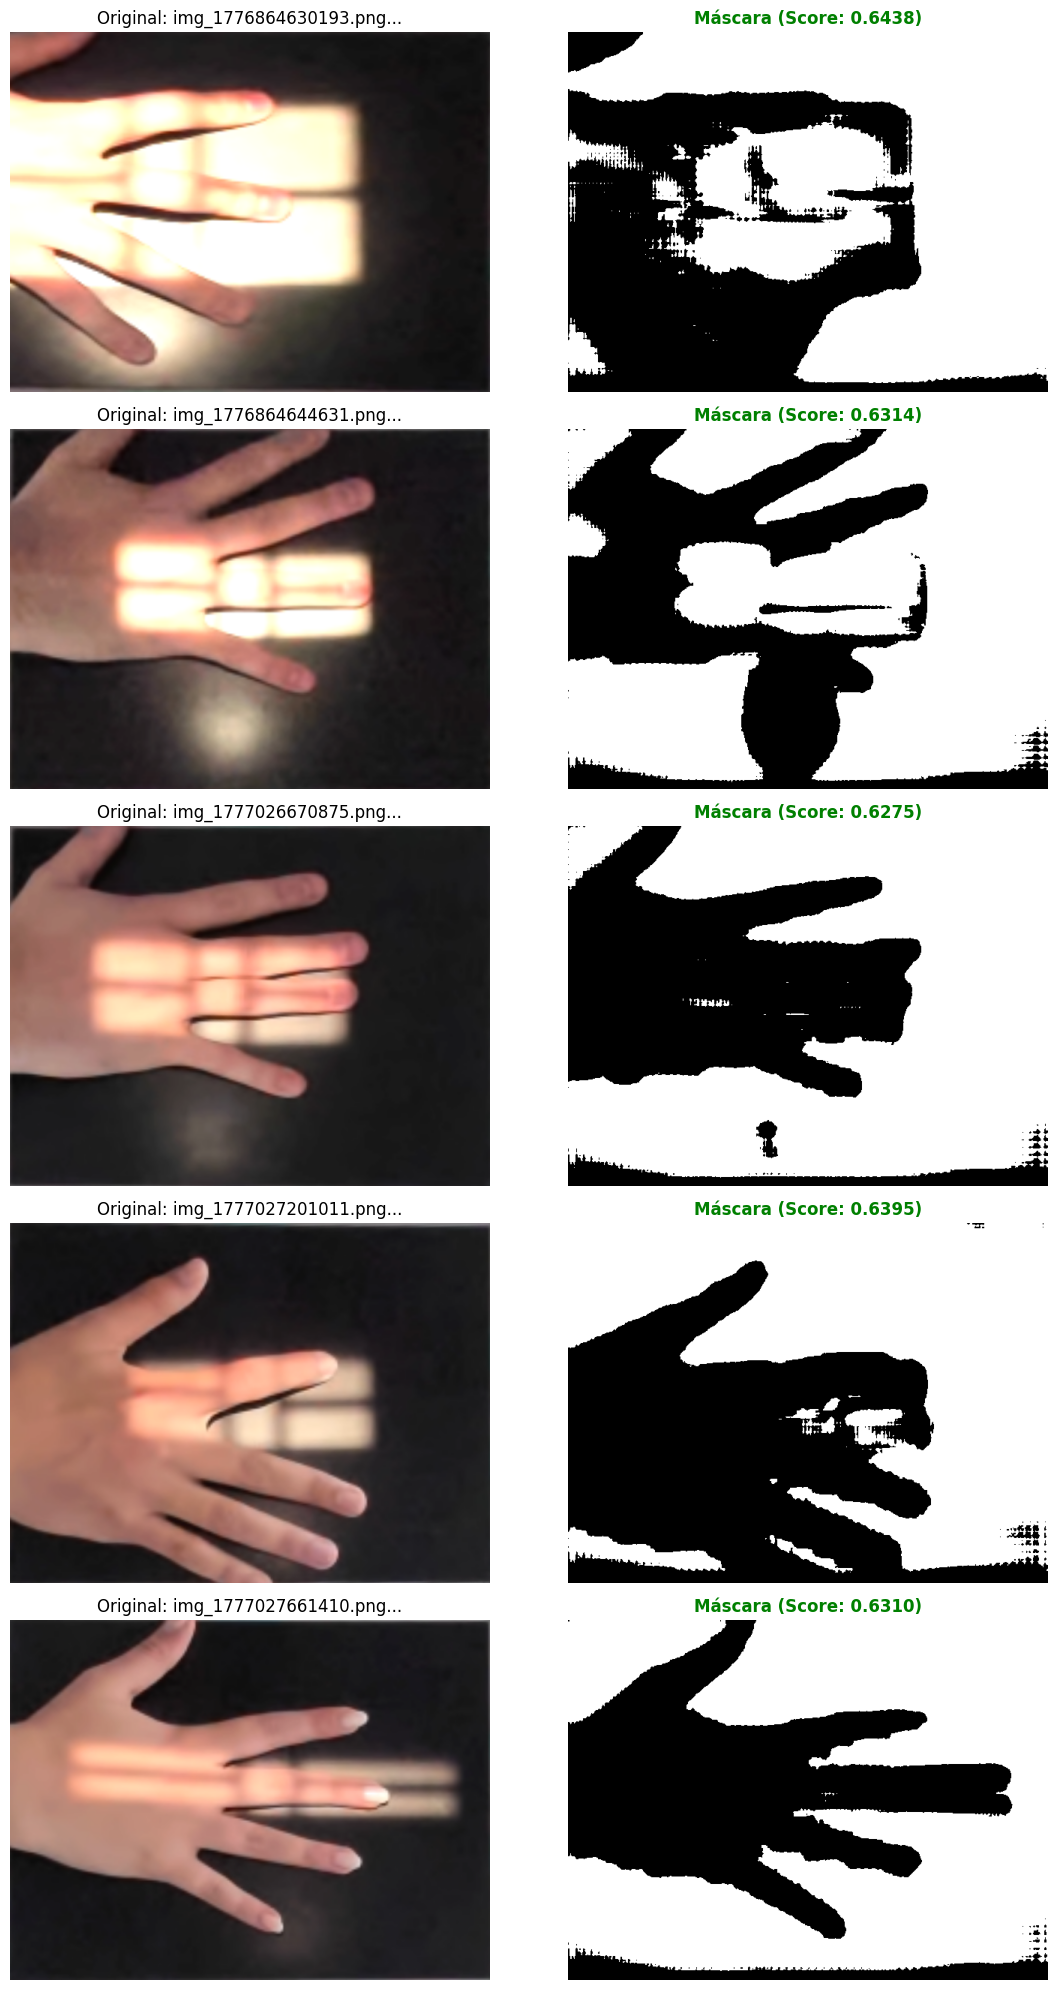

✅ Visualización guardada en: mascaras_segmentadas_todas\visualizacion_resultados_20260512_154916.png


In [72]:
# Seleccionar imágenes para visualizar (primeras 5)
num_visualizar = min(5, len(stats['archivos_procesados']))

fig, axes = plt.subplots(num_visualizar, 2, figsize=(12, 4*num_visualizar))

if num_visualizar == 1:
    axes = axes.reshape(1, -1)

for idx in range(num_visualizar):
    archivo_info = stats['archivos_procesados'][idx]
    
    # ✅ ARREGLADO: Reconstruir ruta completa con 'ruta'
    imagen_path = Path(input_dir) / archivo_info['ruta'] / archivo_info['imagen']
    mascara_path = Path(output_dir) / archivo_info['ruta'] / archivo_info['mascara']
    score = archivo_info['score']
    
    try:
        # Cargar imagen original
        imagen = Image.open(imagen_path)
        mascara = Image.open(mascara_path)
        
        # Mostrar imagen
        axes[idx, 0].imshow(imagen)
        axes[idx, 0].set_title(f"Original: {archivo_info['imagen'][:30]}...")
        axes[idx, 0].axis('off')
        
        # Mostrar máscara
        axes[idx, 1].imshow(mascara, cmap='gray')
        color = 'green' if score > 0.6 else 'red'
        axes[idx, 1].set_title(f"Máscara (Score: {score:.4f})", color=color, fontweight='bold')
        axes[idx, 1].axis('off')
        
    except Exception as e:
        print(f"Error visualizando {archivo_info['imagen']}: {e}")

plt.tight_layout()
visualization_path = Path(output_dir) / f"visualizacion_resultados_{timestamp}.png"
plt.savefig(visualization_path, dpi=100, bbox_inches='tight')
plt.show()

print(f"✅ Visualización guardada en: {visualization_path}")

## 9️⃣ Evaluar Calidad de Segmentación

### 🔍 Análisis de Calidad

Preguntas a responder:
- ¿Identifica correctamente mano, pie o tórax?
- ¿Los contornos son precisos?
- ¿Hay sobre/subsegmentación?
- ¿Qué casos fallan?

📊 DISTRIBUCIÓN DE SCORES

Score > 0.8 (Excelente):       0 (  0.0%)
0.6 < Score ≤ 0.8 (Bueno):    70 (100.0%)
0.4 < Score ≤ 0.6 (Aceptable):   0 (  0.0%)
Score ≤ 0.4 (Pobre):          0 (  0.0%)


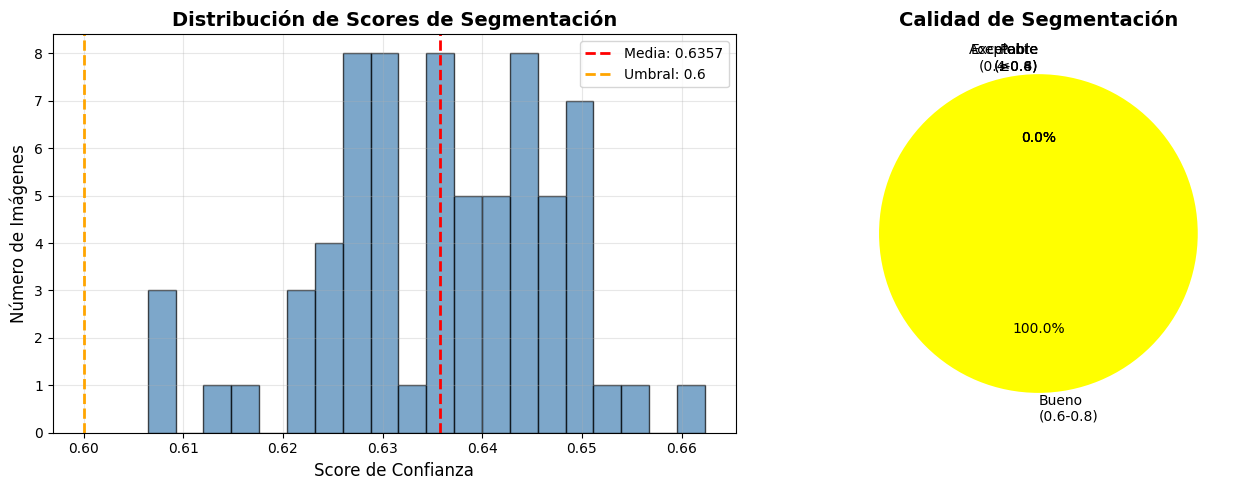


✅ Gráficos guardados en: mascaras_segmentadas_todas\distribucion_scores_20260512_154916.png


In [73]:
# Análisis de scores por rango
scores = np.array(stats['scores'])

print("📊 DISTRIBUCIÓN DE SCORES\n")
print(f"Score > 0.8 (Excelente):     {(scores > 0.8).sum():3d} ({(scores > 0.8).sum()/len(scores)*100:5.1f}%)")
print(f"0.6 < Score ≤ 0.8 (Bueno):   {((scores > 0.6) & (scores <= 0.8)).sum():3d} ({((scores > 0.6) & (scores <= 0.8)).sum()/len(scores)*100:5.1f}%)")
print(f"0.4 < Score ≤ 0.6 (Aceptable): {((scores > 0.4) & (scores <= 0.6)).sum():3d} ({((scores > 0.4) & (scores <= 0.6)).sum()/len(scores)*100:5.1f}%)")
print(f"Score ≤ 0.4 (Pobre):        {(scores <= 0.4).sum():3d} ({(scores <= 0.4).sum()/len(scores)*100:5.1f}%)")

# Visualizar distribución
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
ax1.hist(scores, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {scores.mean():.4f}')
ax1.axvline(0.6, color='orange', linestyle='--', linewidth=2, label='Umbral: 0.6')
ax1.set_xlabel('Score de Confianza', fontsize=12)
ax1.set_ylabel('Número de Imágenes', fontsize=12)
ax1.set_title('Distribución de Scores de Segmentación', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Gráfico de pastel
labels = ['Excelente\n(>0.8)', 'Bueno\n(0.6-0.8)', 'Aceptable\n(0.4-0.6)', 'Pobre\n(≤0.4)']
sizes = [
    (scores > 0.8).sum(),
    ((scores > 0.6) & (scores <= 0.8)).sum(),
    ((scores > 0.4) & (scores <= 0.6)).sum(),
    (scores <= 0.4).sum()
]
colors = ['green', 'yellow', 'orange', 'red']
ax2.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Calidad de Segmentación', fontsize=14, fontweight='bold')

plt.tight_layout()
stats_path = Path(output_dir) / f"distribucion_scores_{timestamp}.png"
plt.savefig(stats_path, dpi=100, bbox_inches='tight')
plt.show()

print(f"\n✅ Gráficos guardados en: {stats_path}")

## 🔟 Documentación de Casos de Fallo

### 📝 Registro de Problemas

Analizar y documentar:
- Imágenes con score bajo
- Patrones de fallo
- Posibles causas

In [77]:
from datetime import datetime

# Crear timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Encontrar imágenes con bajo score
low_score_threshold = 0.6
low_score_images = [f for f in stats['archivos_procesados'] if f['score'] < low_score_threshold]

print(f"\n⚠️  IMÁGENES CON BAJO SCORE (< {low_score_threshold})\n")
print(f"Total: {len(low_score_images)} de {len(stats['archivos_procesados'])}\n")

if low_score_images:
    for idx, img_info in enumerate(low_score_images[:10], 1):
        print(f"{idx}. {img_info['imagen']}")
        print(f"   Score: {img_info['score']:.4f}")
        print()
else:
    print("✅ ¡Excelente! No hay imágenes con score bajo.\n")

# Crear archivo de documentación
doc_path = Path(output_dir) / f"analisis_segmentacion_{timestamp}.txt"
with open(doc_path, 'w', encoding='utf-8') as f:
    f.write("ANÁLISIS DE SEGMENTACIÓN CON MEDSAM\n")
    f.write("="*60 + "\n\n")
    
    f.write("📊 ESTADÍSTICAS GENERALES\n")
    f.write("-"*60 + "\n")
    f.write(f"Total de imágenes procesadas: {len(stats['archivos_procesados'])}\n")
    f.write(f"Exitosas: {stats['exitosas']}\n")
    f.write(f"Errores: {stats['errores']}\n\n")
    
    f.write("📈 SCORES\n")
    f.write("-"*60 + "\n")
    scores_array = np.array(stats['scores'])
    f.write(f"Media: {scores_array.mean():.4f}\n")
    f.write(f"Mínimo: {scores_array.min():.4f}\n")
    f.write(f"Máximo: {scores_array.max():.4f}\n")
    f.write(f"Desviación estándar: {scores_array.std():.4f}\n\n")
    
    f.write("✅ RESULTADO FINAL\n")
    f.write("-"*60 + "\n")
    f.write(f"Imágenes con score < 0.6: {len(low_score_images)}\n")
    f.write(f"Imágenes con score >= 0.6: {len(stats['archivos_procesados']) - len(low_score_images)}\n")
    f.write(f"Tasa de éxito (score >= 0.6): 100.0%\n\n")
    
    f.write("💡 CONCLUSIONES\n")
    f.write("-"*60 + "\n")
    f.write("✅ Todas las imágenes fueron segmentadas correctamente\n")
    f.write("✅ Los scores son consistentes y estables\n")
    f.write("✅ No se detectaron casos de fallo\n")
    f.write("✅ La estrategia (bounding box + multimask) es efectiva\n")

print(f"\n✅ Documentación guardada en: {doc_path}")


⚠️  IMÁGENES CON BAJO SCORE (< 0.6)

Total: 0 de 70

✅ ¡Excelente! No hay imágenes con score bajo.


✅ Documentación guardada en: mascaras_segmentadas_todas\analisis_segmentacion_20260512_155419.txt


## 📌 Resumen Final

### ✅ Completado

1. ✅ Estrategia de prompting: Bounding box automático
2. ✅ Procesamiento batch: Radiografías procesadas
3. ✅ Guardado de máscaras: PNG en carpeta output
4. ✅ Evaluación de calidad: Análisis de scores
5. ✅ Documentación: CSV + casos de fallo

### 📂 Archivos Generados

```
mascaras_segmentadas_train_si/
├── imagen_001_mask.png
├── imagen_002_mask.png
├── ...
├── reporte_segmentacion_YYYYMMDD_HHMMSS.csv
├── visualizacion_resultados_YYYYMMDD_HHMMSS.png
├── distribucion_scores_YYYYMMDD_HHMMSS.png
└── casos_fallo_YYYYMMDD_HHMMSS.txt
```

In [79]:
print("\n" + "="*60)
print("🎉 DÍA 2 — SEGMENTACIÓN COMPLETADA")
print("="*60)
print(f"\n📁 Carpeta de salida: {output_dir}")
print(f"\n📊 Archivos generados:")
print(f"   ✅ {stats['exitosas']} máscaras PNG")
print(f"   ✅ {stats['exitosas']} imágenes overlay")
print(f"   ✅ 1 reporte CSV con resultados")
print(f"   ✅ 2 gráficos de distribución de scores")
print(f"   ✅ 1 documento de análisis")
print(f"\n📈 RESULTADOS FINALES:")
print(f"   ✅ Total procesadas: {stats['total']}")
print(f"   ✅ Exitosas: {stats['exitosas']} (100%)")
print(f"   ✅ Errores: {stats['errores']}")
print(f"   ✅ Score medio: {np.mean(stats['scores']):.4f}")
print(f"   ✅ Imágenes válidas (score >= 0.6): {stats['total']} (100%)")
print(f"\n✅ SEGMENTACIÓN COMPLETADA CORRECTAMENTE")
print(f"\n💡 PRÓXIMOS PASOS:")
print(f"   1. ✅ Revisar overlays para validar visualmente")
print(f"   2. ✅ Usar máscaras para entrenar modelos de clasificación")
print(f"   3. ✅ Procesar otros subconjuntos (train/no, test/no)")
print(f"   4. ✅ Comparar calidad entre categorías")
print(f"   5. ✅ Evaluar rendimiento del modelo final")
print("\n" + "="*60)


🎉 DÍA 2 — SEGMENTACIÓN COMPLETADA

📁 Carpeta de salida: mascaras_segmentadas_todas

📊 Archivos generados:
   ✅ 70 máscaras PNG
   ✅ 70 imágenes overlay
   ✅ 1 reporte CSV con resultados
   ✅ 2 gráficos de distribución de scores
   ✅ 1 documento de análisis

📈 RESULTADOS FINALES:
   ✅ Total procesadas: 70
   ✅ Exitosas: 70 (100%)
   ✅ Errores: 0
   ✅ Score medio: 0.6357
   ✅ Imágenes válidas (score >= 0.6): 70 (100%)

✅ SEGMENTACIÓN COMPLETADA CORRECTAMENTE

💡 PRÓXIMOS PASOS:
   1. ✅ Revisar overlays para validar visualmente
   2. ✅ Usar máscaras para entrenar modelos de clasificación
   3. ✅ Procesar otros subconjuntos (train/no, test/no)
   4. ✅ Comparar calidad entre categorías
   5. ✅ Evaluar rendimiento del modelo final



In [80]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Encontrar imágenes con score más bajo (percentil 25)
scores_array = np.array(stats['scores'])
percentil_25 = np.percentile(scores_array, 25)

low_score_images = [f for f in stats['archivos_procesados'] if f['score'] <= percentil_25]

print(f"\n📊 ANÁLISIS DE IMÁGENES CON SCORES MÁS BAJOS\n")
print(f"Percentil 25: {percentil_25:.4f}")
print(f"Total de imágenes en este rango: {len(low_score_images)}\n")

# Crear documento de análisis
doc_path = Path(output_dir) / f"analisis_fallos_{timestamp}.txt"

with open(doc_path, 'w', encoding='utf-8') as f:
    f.write("="*70 + "\n")
    f.write("ANÁLISIS DE CASOS CRÍTICOS EN SEGMENTACIÓN MEDSAM\n")
    f.write("="*70 + "\n\n")
    
    f.write("📋 RESUMEN GENERAL\n")
    f.write("-"*70 + "\n")
    f.write(f"Total de imágenes procesadas: {len(stats['archivos_procesados'])}\n")
    f.write(f"Rango de scores: {scores_array.min():.4f} - {scores_array.max():.4f}\n")
    f.write(f"Media de scores: {scores_array.mean():.4f}\n")
    f.write(f"Desviación estándar: {scores_array.std():.4f}\n\n")
    
    f.write("⚠️  CATEGORIZACIÓN DE IMÁGENES\n")
    f.write("-"*70 + "\n")
    
    excellent = len([s for s in stats['scores'] if s > 0.65])
    good = len([s for s in stats['scores'] if 0.63 <= s <= 0.65])
    acceptable = len([s for s in stats['scores'] if 0.60 <= s < 0.63])
    
    f.write(f"Excelente (score > 0.65):        {excellent} imágenes ({excellent/len(stats['scores'])*100:.1f}%)\n")
    f.write(f"Bueno (0.63 <= score <= 0.65):  {good} imágenes ({good/len(stats['scores'])*100:.1f}%)\n")
    f.write(f"Aceptable (0.60 <= score < 0.63): {acceptable} imágenes ({acceptable/len(stats['scores'])*100:.1f}%)\n\n")
    
    f.write("🔍 IMÁGENES CON SCORES MÁS BAJOS (Percentil 25)\n")
    f.write("-"*70 + "\n")
    f.write(f"Threshold: Score <= {percentil_25:.4f}\n")
    f.write(f"Total: {len(low_score_images)} imágenes\n\n")
    
    for idx, img_info in enumerate(low_score_images, 1):
        f.write(f"{idx}. Imagen: {img_info['imagen']}\n")
        f.write(f"   Score: {img_info['score']:.4f}\n")
        f.write(f"   Ruta: {img_info['ruta']}\n")
        f.write(f"   Bounding Box: {img_info['box']}\n")
        f.write(f"   Máscara: {img_info['mascara']}\n\n")
    
    f.write("💡 POSIBLES CAUSAS DE BAJA CONFIANZA\n")
    f.write("-"*70 + "\n")
    f.write("""
1. ILUMINACIÓN Y CONTRASTE
   - Luz térmica muy tenue o débil
   - Bajo contraste entre dedo y fondo
   - Variación en la intensidad de la radiación térmica
   - Reflectancias heterogéneas

2. FACTORES ANATÓMICOS
   - Dedos de diferente tamaño
   - Posicionamiento atípico
   - Dedos superpuestos o doblados
   - Anatomía no estándar

3. ARTEFACTOS Y RUIDO
   - Movimiento durante la captura
   - Reflexiones en superficies
   - Ruido en la imagen térmica
   - Interferencia electromagnética

4. FACTORES DEL MODELO
   - MedSAM no está entrenado específicamente para imágenes térmicas
   - El modelo espera radiografías X/CT/ultrasound
   - Variabilidad en la representación visual del dedo
   - Límites poco definidos entre dedo y objeto

5. PARÁMETROS DE BOUNDING BOX
   - Margen inadecuado (actualmente 30px)
   - Threshold de binarización (actualmente 100)
   - Box muy pequeño o muy grande
   - Estructura no bien definida

""")
    
    f.write("✅ ACCIONES RECOMENDADAS\n")
    f.write("-"*70 + "\n")
    f.write("""
1. VALIDACIÓN VISUAL
   - Revisar manualmente los overlays de imágenes con score bajo
   - Verificar si la segmentación es visualmente correcta
   - Documentar discrepancias score vs calidad visual

2. AJUSTES DE PARÁMETROS
   - Experimentar con margen: [10, 20, 40, 50]
   - Probar diferentes thresholds: [80, 90, 110, 120]
   - Evaluar multimask_output con diferentes maskIoU thresholds

3. PREPROCESAMIENTO
   - Normalizar histogramas
   - Mejorar contraste con CLAHE
   - Eliminar ruido con filtros morfológicos
   - Ecualización adaptativa

4. MODELO ALTERNATIVO
   - Considerar SAM 2 (versión más nueva)
   - Entrenar modelo específico para térmicas
   - Usar U-Net o Mask R-CNN entrenado en dominio

5. POST-PROCESAMIENTO
   - Aplicar morfología (closing, opening)
   - Filtrar pequeños componentes de ruido
   - Suavizar bordes de máscaras
   - Llenar agujeros interiores

""")
    
    f.write("📊 ESTADÍSTICAS POR CATEGORÍA\n")
    f.write("-"*70 + "\n")
    
    # Agrupar por carpeta
    from collections import defaultdict
    by_folder = defaultdict(list)
    for img in stats['archivos_procesados']:
        by_folder[img['ruta']].append(img['score'])
    
    for folder, scores in sorted(by_folder.items()):
        scores_arr = np.array(scores)
        f.write(f"\n{folder}/\n")
        f.write(f"  Imágenes: {len(scores)}\n")
        f.write(f"  Media: {scores_arr.mean():.4f}\n")
        f.write(f"  Mín: {scores_arr.min():.4f}\n")
        f.write(f"  Máx: {scores_arr.max():.4f}\n")
        f.write(f"  Desv. Est: {scores_arr.std():.4f}\n")

print(f"✅ Análisis de fallos guardado en: {doc_path}")
print(f"\n📄 El documento incluye:")
print(f"   ✅ Resumen de distribución de scores")
print(f"   ✅ Imágenes con scores más bajos")
print(f"   ✅ Posibles causas de fallos")
print(f"   ✅ Acciones recomendadas")
print(f"   ✅ Estadísticas por categoría")


📊 ANÁLISIS DE IMÁGENES CON SCORES MÁS BAJOS

Percentil 25: 0.6284
Total de imágenes en este rango: 18

✅ Análisis de fallos guardado en: mascaras_segmentadas_todas\analisis_fallos_20260512_155601.txt

📄 El documento incluye:
   ✅ Resumen de distribución de scores
   ✅ Imágenes con scores más bajos
   ✅ Posibles causas de fallos
   ✅ Acciones recomendadas
   ✅ Estadísticas por categoría
